<a href="https://colab.research.google.com/github/sohan765/project1/blob/main/Student_mental_health_score_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv(r"/content/drive/MyDrive/Student Social Media And Mental Health Impact.csv")

In [8]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [9]:
df.shape

(5000, 13)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [11]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [12]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [13]:
df.tail()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7
4999,19,Male,China,Undergraduate,WeChat,Entertainment,5.4,177,1.2,1.5,6.3,High,6.1


In [14]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Academic_Level,0
Most_Used_Platform,0
Purpose_Of_Use,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,0
Physical_Activity_Hours,0


In [15]:
df.duplicated().sum()

np.int64(2)

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

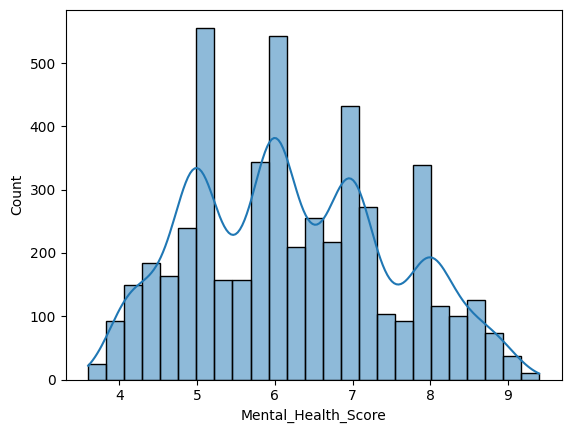

In [16]:
# now we perform the EDA
sns.histplot(df["Mental_Health_Score"],kde = True)

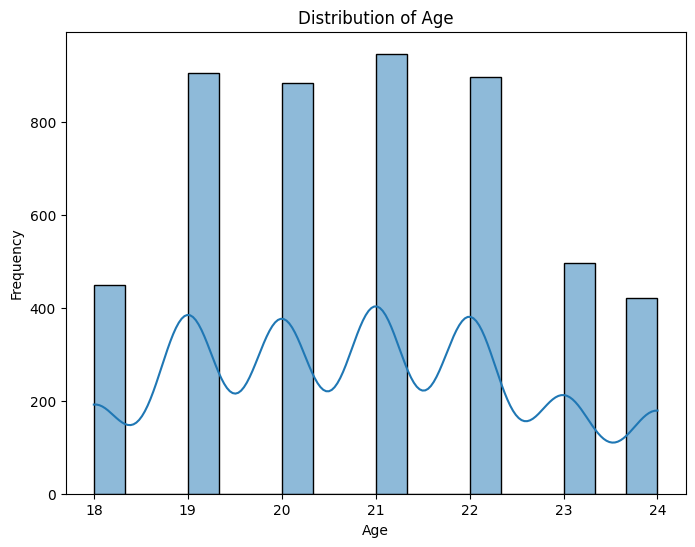

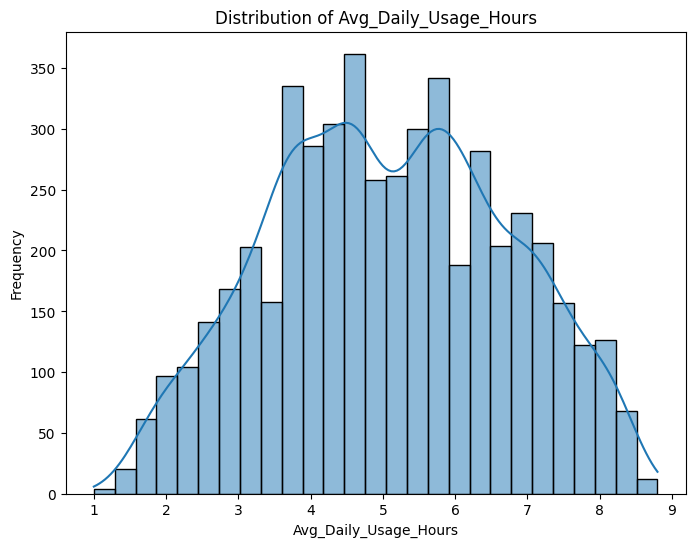

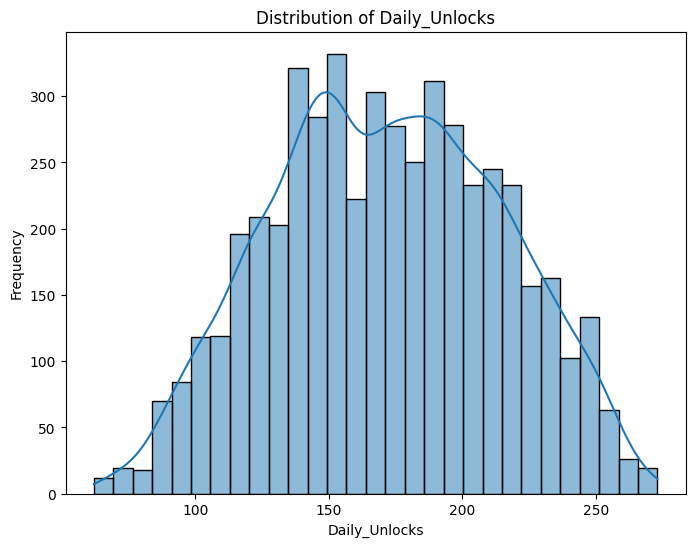

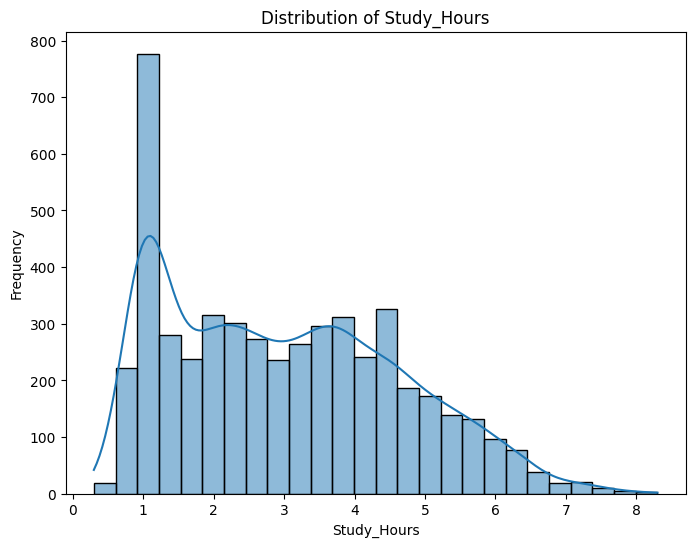

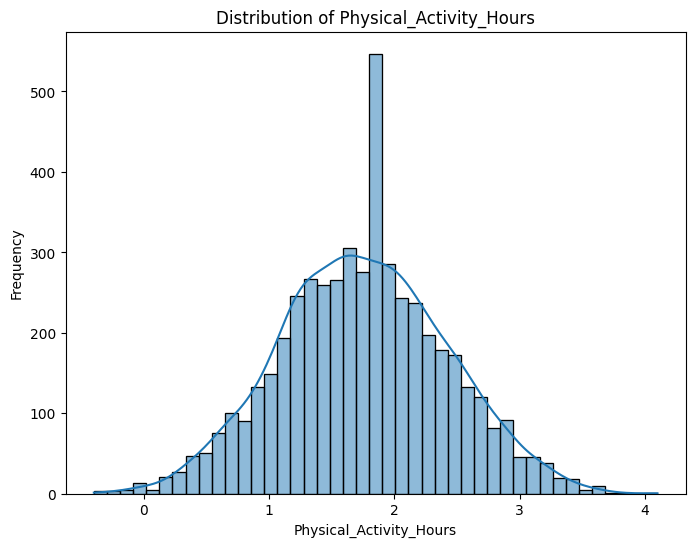

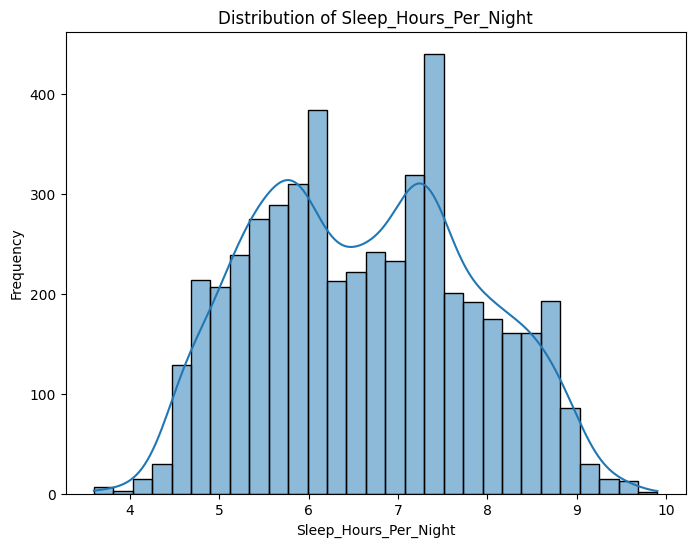

In [17]:
numeric_columns = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',]
for col in numeric_columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

<Axes: >

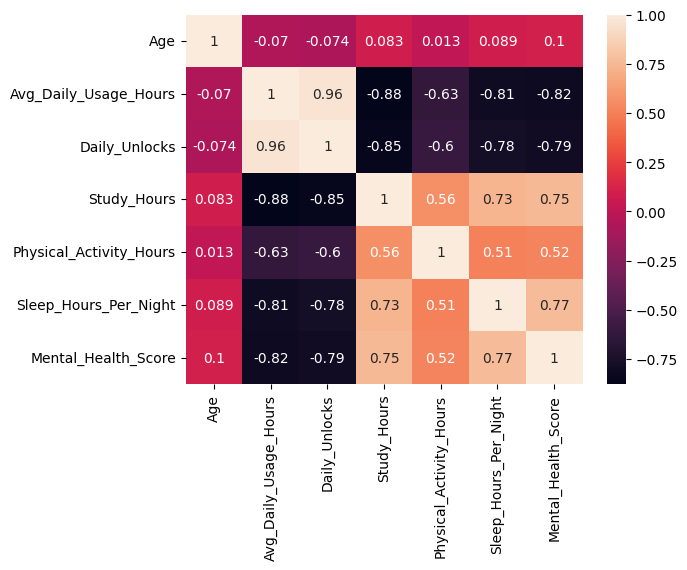

In [18]:
sns.heatmap(df.corr(numeric_only=True),annot = True)

In [19]:
df["Stress_Level"].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

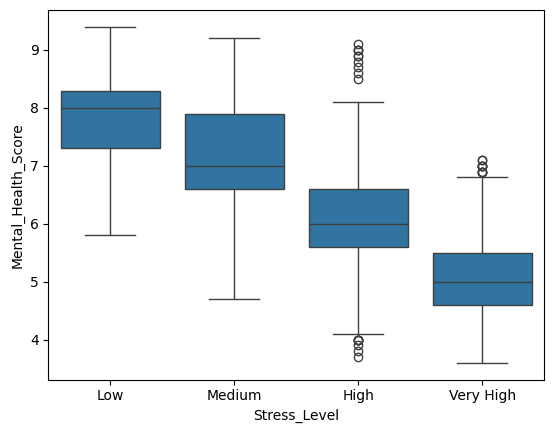

In [20]:
level = ['Low','Medium', 'High', 'Very High']
sns.boxplot(x="Stress_Level",y="Mental_Health_Score",data = df,order = level)

In [21]:
df['Purpose_Of_Use'].unique()

array(['Networking', 'Education', 'Entertainment', 'News'], dtype=object)

<Axes: xlabel='Purpose_Of_Use', ylabel='Mental_Health_Score'>

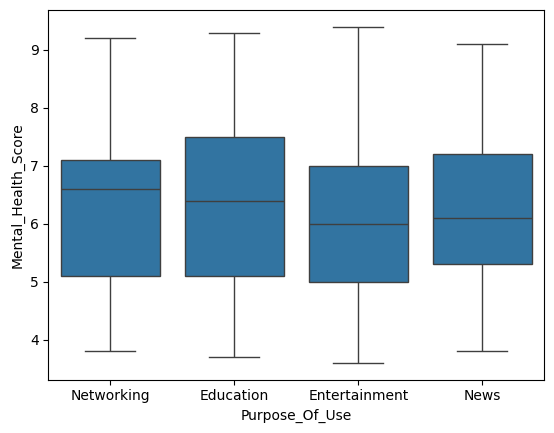

In [22]:
level1 = ['Networking', 'Education', 'Entertainment', 'News']
sns.boxplot(x="Purpose_Of_Use",y="Mental_Health_Score",data = df,order=level1)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

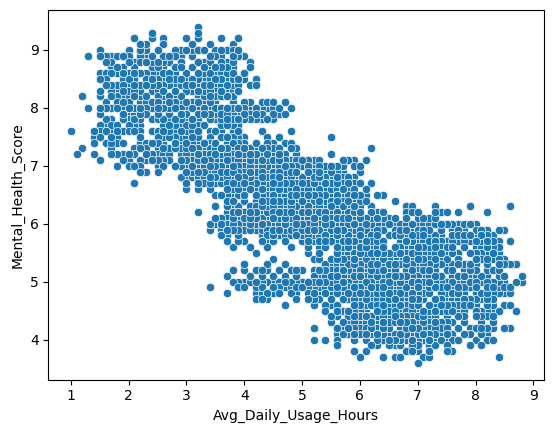

In [23]:
sns.scatterplot(x='Avg_Daily_Usage_Hours',y='Mental_Health_Score',data = df)

In [24]:
df.columns


Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

<Axes: xlabel='Daily_Unlocks', ylabel='Mental_Health_Score'>

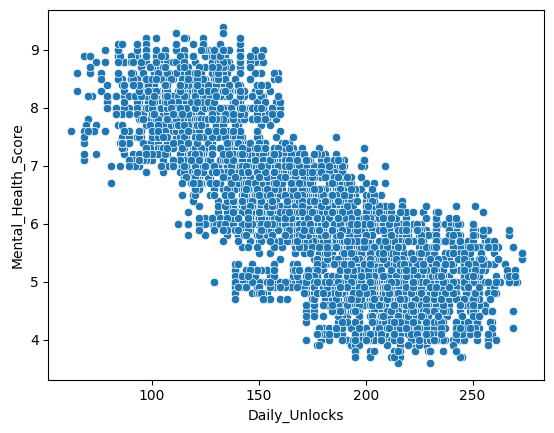

In [25]:
sns.scatterplot(x='Daily_Unlocks',y='Mental_Health_Score',data = df)

<Axes: xlabel='Study_Hours', ylabel='Mental_Health_Score'>

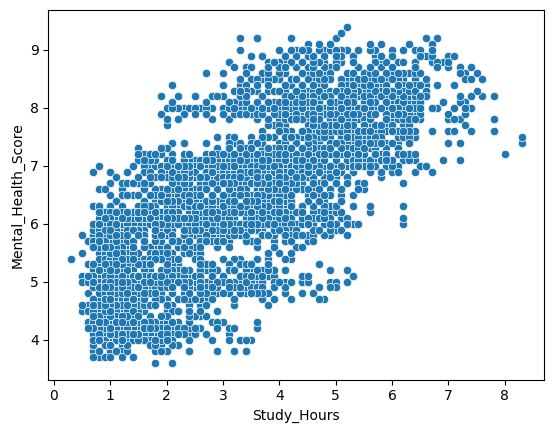

In [26]:
sns.scatterplot(x='Study_Hours',y='Mental_Health_Score',data = df)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

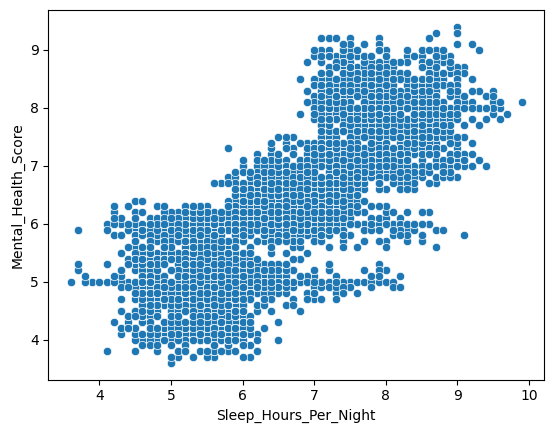

In [27]:
sns.scatterplot(x='Sleep_Hours_Per_Night',y='Mental_Health_Score',data = df)

<Axes: xlabel='Physical_Activity_Hours', ylabel='Mental_Health_Score'>

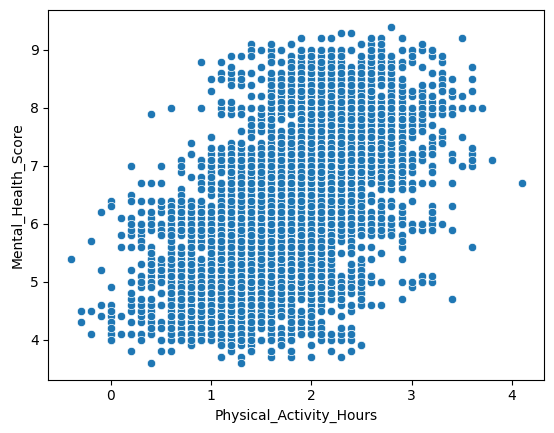

In [28]:
sns.scatterplot(x='Physical_Activity_Hours',y='Mental_Health_Score',data = df)

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

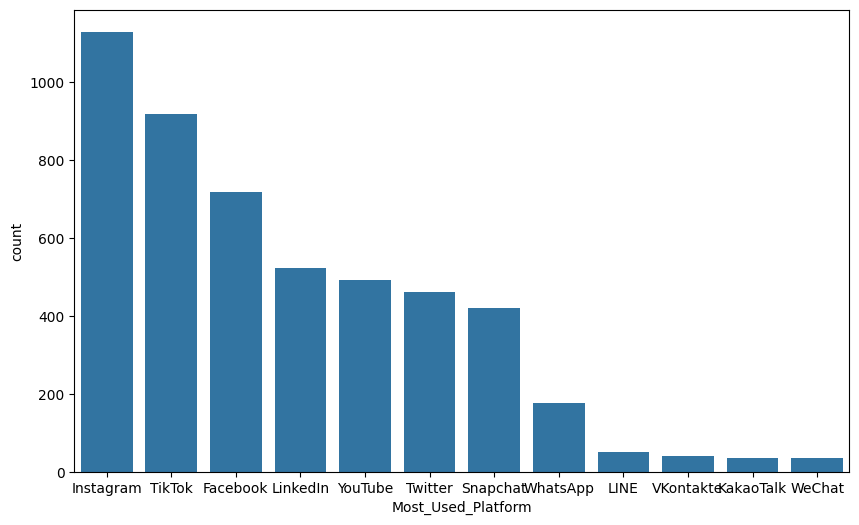

In [29]:
plt.figure(figsize=(10,6))
sns.countplot(x = df['Most_Used_Platform'],order = df['Most_Used_Platform'].value_counts().index)

In [30]:
numeric_columns = ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night','Mental_Health_Score']

In [31]:
Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)
IQR = Q3- Q1
lower_bound = Q1 - 1.5*IQR
upperbound = Q3 + 1.5*IQR
outlier = (lower_bound > df[numeric_columns]) | (upperbound < df[numeric_columns])
print(outlier.sum())


Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [32]:
df = df.drop_duplicates()

In [33]:
# converting negative or unrealstatic value to the realstuc values
df['Physical_Activity_Hours']  = df['Physical_Activity_Hours'].clip(lower=0)

In [34]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [35]:
nums_col = df.select_dtypes(include = 'number')
nums_col.skew()

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


In [36]:
top_country = df["Country"].value_counts().index[:20].tolist()

In [37]:
def group_countries(country):
  if country in top_country:
    return country
  else:
    return "Other"


In [38]:
df['Grouped_country'] = df['Country'].apply(group_countries)

In [39]:
df['Grouped_country'].value_counts()

,count
Grouped_country,
Other,2519
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


In [40]:
skwews_col = ['Study_Hours']
other_numeric_cols = ['Age',  'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       ]

In [41]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Grouped_country'],
      dtype='object')

In [42]:
ordinal_col = ['Stress_Level']
normal_col = ['Gender', 'Academic_Level', 'Purpose_Of_Use', 'Most_Used_Platform', 'Grouped_country']

In [43]:
from sklearn.model_selection import train_test_split
feature_col = skwews_col +other_numeric_cols+ordinal_col + normal_col
target_col = ['Mental_Health_Score']
X = df[feature_col]
y = df[target_col]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.30,random_state=42)

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder,OrdinalEncoder
skew_pipeline = Pipeline(steps = [
    ('log_transform',FunctionTransformer(np.log1p)),
    ('scaler',StandardScaler())
])
plain_numeric_pipeline = Pipeline(steps = [
    ('scaler',StandardScaler())
])
ordinal_pipeline = Pipeline(steps = [
    ('ordinal_encoder',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))
])
normal_pipeline = Pipeline(steps = [
    ('one_hot_encoder',OneHotEncoder(handle_unknown='ignore'))
])


In [45]:
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer(transformers = [
    ('Skewed_Pipeline',skew_pipeline,skwews_col),
    ('Plain_Numeric',plain_numeric_pipeline,other_numeric_cols),
    ('Ordinal',ordinal_pipeline,ordinal_col),
    ('Normal',normal_pipeline,normal_col)
])

In [46]:
# # Linear Regressiong
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
# lr_pipeline = Pipeline(steps = [
#     ('preprocessor',preprocessor),
#     ('regressor',LinearRegression())
# ])
# lr_pipeline.fit(X_train,y_train)
# lr_pred = lr_pipeline.predict(X_test)
# lr_preds_train = lr_pipeline.predict(X_test)
# lr_mse = mean_squared_error(y_test,lr_pred)
# lr_r2_testing = r2_score(y_test,lr_pred)
# print("R2 score is :",lr_r2)
# lr_r2_training = r2_score(y_train,lr_preds_train)

# print(f"Accuracy of Training {lr_r2_training}")
# print(f"Accuracy of Testing {lr_r2_testing}")

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Train the model
lr_pipeline.fit(X_train, y_train)

# Predictions
lr_pred_test = lr_pipeline.predict(X_test)
lr_pred_train = lr_pipeline.predict(X_train)

# Metrics
lr_mse = mean_squared_error(y_test, lr_pred_test)
lr_mae = mean_absolute_error(y_test, lr_pred_test)
lr_r2_testing = r2_score(y_test, lr_pred_test)
lr_r2_training = r2_score(y_train, lr_pred_train)

print("Training R² Score:", lr_r2_training)
print("Testing R² Score :", lr_r2_testing)
print("Mean Squared Error:", lr_mse)
print("Mean Absolute Error:", lr_mae)

Training R² Score: 0.7409272064397521
Testing R² Score : 0.7527139914707695
Mean Squared Error: 0.43432748637781643
Mean Absolute Error: 0.5166316386846717


In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
rf_pipeline = Pipeline(steps = [
    ('preprocessor',preprocessor),
    ('random_forest',RandomForestRegressor())
])
rf_pipeline.fit(X_train,y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_preds_train = rf_pipeline.predict(X_train)
rf_mse = mean_squared_error(y_test,rf_pred)
rf_mae = mean_absolute_error(y_test,rf_pred)
rf_r2_testing = r2_score(y_test,rf_pred)

rf_r2_training = r2_score(y_train,rf_preds_train)

print(f"Accuracy of Training {rf_r2_training}")
print(f"Accuracy of Testing {rf_r2_testing}")
print("Mean Squared Error:", rf_mse)
print("Mean Absolute Error:", rf_mae)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy of Training 0.9836113193890704
Accuracy of Testing 0.8936488669456866
Mean Squared Error: 0.18679269631000012
Mean Absolute Error: 0.31483813333333355


In [48]:
print(rf_pipeline)

print(rf_pipeline.get_params().keys())

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('Skewed_Pipeline',
                                                  Pipeline(steps=[('log_transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Study_Hours']),
                                                 ('Plain_Numeric',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Avg_Daily_Usage_Hours',
                                                   'Daily_Unlocks',
                                    